# Tutorial: fmdtools basics

::: {.content-hidden}
```
Copyright © 2024, United States Government, as represented by the Administrator of the National Aeronautics and Space Administration. All rights reserved.

The “"Fault Model Design tools - fmdtools version 2"” software is licensed under the Apache License, Version 2.0 (the "License"); you may not use this file except in compliance with the License. You may obtain a copy of the License at http://www.apache.org/licenses/LICENSE-2.0. 

Unless required by applicable law or agreed to in writing, software distributed under the License is distributed on an "AS IS" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied. See the License for the specific language governing permissions and limitations under the License.
```
:::

## Overview
This tutorial shows the basics of:

1. working with fmdtools to model a system (in this example, a multirotor drone with a few variants), 

2. simulating a model in nominal and hazardous scenarios, and

3. analyzing and visualizing the results of simulations. 

## Multorotor Drone folder

The `multirotor_drone` folder has a few different models that are meant to represent **different types of models** that can be built in fmdtools (in terms of fidelity) and showcase how **more detailed models** can be built from **less detailed models.**

The models in this folder include:

- `model_static.py`: a multirotor drone simulated at a single timestep with very basic abstract behaviors to capture failure propagation in a "static flight" case

- `model_dynamic.py`: an extended version of this drone with dynamic behaviors (e.g., basic flight dynamics, battery usage, etc.)

- `model_hierarchical.py`: a version with multiple component architectures embodying the "StoreEE" (battery architecture) and "AffectDOF" (line/rotor architecture) functions

- `model_rural.py`: a version that flies in a rural scenario (viewing the area in a field)

- `model_urban.py`: a version that over buildings in an urban setting 

## Multirotor Drone Structure 

Models in fmdtools can take many different forms, depending on the use-case. When we want to model how different behaviors of a system interact, we often represent the system as a `FunctionArchitecture` that is made up of `Function` objects that are connected with each other via `Flow` objects.

## Drone Functions

- `store_ee`: Store the electrical energy that powers the system (e.g., batteries)

- `dist_ee`: Distribute the electrical energy that powers the system (e.g., wiring and circuitry)

- `affect_dof`: Modify the position and velocity of the system (e.g., rotor architecture)

- `ctl_dof`: Control the position and velocity of the system to its desired state (e.g., control system)

- `plan_path`: Plan the desired trajectory of the drone and produce the neccesary controls (e.g., navigation)

- `hold_payload`: Structurally support the weight of the drone and its payloads (e.g., structures)

- `view_env`: View the environment (e.g., camera)


## Drone Flows

- `force_st`: Force connecting the body of the drone with the ground

- `force_lin`: Force connecting the rotors with the body of the drone

- `ee_1`: Electricity out of the battery (to be distributed)

- `ee_mot`: Electricity to the motors

- `ee_ctl`: Electricity to the electronics

- `ctl`: Control signals to the motors

- `dofs`: Degrees of freedom (trajectory, velocity) of the drone

- `des_traj`: Desired trajectory of the drone


## Drone model file

To get an idea of what a model file looks like (as well as the different pieces), look through `model_static.py`. Here we import this model to look at its structure:

In [1]:
import inspect
from fmdtools_examples.multirotor_drone.model_static import Drone, EE, StoreEE
print(inspect.getsource(Drone))

class Drone(FunctionArchitecture):
    """Static multirotor drone model (executes in a single timestep)."""

    default_sp = {'end_time': 0}

    def init_architecture(self, **kwargs):
        # add flows to the model
        self.add_flow("force_st", Force)
        self.add_flow("force_lin", Force)
        self.add_flow("ee_1", EE)
        self.add_flow("ee_mot", EE)
        self.add_flow("ee_ctl", EE)
        self.add_flow("ctl", Control)
        self.add_flow("dofs", DOFs)
        self.add_flow("des_traj", DesTraj)
        # add functions to the model
        self.add_fxn("store_ee", StoreEE, "ee_1", "force_st")
        self.add_fxn("dist_ee", DistEE, "ee_1", "ee_mot", "ee_ctl", "force_st")
        self.add_fxn("affect_dof", AffectDOF, "ee_mot", "ctl", "dofs", "force_lin")
        self.add_fxn("ctl_dof", CtlDOF, "ee_ctl", "des_traj", "ctl", "dofs", "force_st")
        self.add_fxn("plan_path", PlanPath, "ee_ctl", "des_traj", "force_st", "dofs")
        self.add_fxn("hold_payload", 

## Drone Architecture

To instantiate the model, you can use:

In [2]:
mdl = Drone()
mdl

drone Drone
- t=Time(time=-0.1, timers={})
- m=Mode(mode='nominal', faults=set(), sub_faults=False)
FLOWS:
- force_st=Force(s=(support=1.0))
- force_lin=Force(s=(support=1.0))
- ee_1=EE(s=(rate=1.0, effort=1.0))
- ee_mot=EE(s=(rate=1.0, effort=1.0))
- ee_ctl=EE(s=(rate=1.0, effort=1.0))
- ctl=Control(s=(forward=1.0, upward=1.0))
- dofs=DOFs(s=(vertvel=1.0, planvel=1.0, planpwr=1.0, uppwr=1.0, x=0.0, y=0.0, z=0.0))
- des_traj=DesTraj(s=(dx=1.0, dy=0.0, dz=0.0, power=1.0))
FXNS:
- store_ee=StoreEE(s=(soc=100.0), m=(mode='nominal', faults=set(), sub_faults=False))
- dist_ee=DistEE(s=(ee_tr=1.0, ee_te=1.0), m=(mode='nominal', faults=set(), sub_faults=False))
- affect_dof=AffectDOF(s=(e_to=1.0, e_ti=1.0, ct=1.0, mt=1.0, pt=1.0), m=(mode='nominal', faults=set(), sub_faults=False))
- ctl_dof=CtlDOF(s=(cs=1.0, power=1.0), m=(mode='nominal', faults=set(), sub_faults=False))
- plan_path=PlanPath(m=(mode='nominal', faults=set(), sub_faults=False))
- hold_payload=HoldPayload(s=(force_gr=1.0), m=(m

## Interacting with a FunctionArchitecture

It can be helpful to look at the major pieces of a the Drone class:

In [3]:
mdl.sp # simulation parameter--determines how long the simulation will run and in what configuration

SimParam(phases=(('na', 0.0, 0),), start_time=0.0, end_time=0.0, track_times=('all',), dt=1.0, units='hr', end_condition='', use_local=True, with_loadings=False, run_stochastic=False, track_pdf=False)

In [4]:
mdl.fxns # flow dictionary

{'store_ee': store_ee StoreEE
 - t=Time(time=-0.1, timers={})
 - s=StoreEEState(soc=100.0)
 - m=StoreEEMode(mode='nominal', faults=set(), sub_faults=False)
 - ee_out=EE(s=(rate=1.0, effort=1.0))
 - fs=Force(s=(support=1.0)),
 'dist_ee': dist_ee DistEE
 - t=Time(time=-0.1, timers={})
 - s=DistEEState(ee_tr=1.0, ee_te=1.0)
 - m=DistEEMode(mode='nominal', faults=set(), sub_faults=False)
 - ee_in=EE(s=(rate=1.0, effort=1.0))
 - ee_mot=EE(s=(rate=1.0, effort=1.0))
 - ee_ctl=EE(s=(rate=1.0, effort=1.0))
 - st=Force(s=(support=1.0)),
 'affect_dof': affect_dof AffectDOF
 - t=Time(time=-0.1, timers={})
 - s=AffectDOFState(e_to=1.0, e_ti=1.0, ct=1.0, mt=1.0, pt=1.0)
 - m=AffectDOFMode(mode='nominal', faults=set(), sub_faults=False)
 - ee_in=EE(s=(rate=1.0, effort=1.0))
 - ctl_in=Control(s=(forward=1.0, upward=1.0))
 - dofs=DOFs(s=(vertvel=1.0, planvel=1.0, planpwr=1.0, uppwr=1.0, x=0.0, y=0.0, z=0.0))
 - force=Force(s=(support=1.0)),
 'ctl_dof': ctl_dof CtlDOF
 - t=Time(time=-0.1, timers={})
 - 

In [5]:
mdl.flows

{'force_st': force_st Force
 - s=ForceState(support=1.0),
 'force_lin': force_lin Force
 - s=ForceState(support=1.0),
 'ee_1': ee_1 EE
 - s=EEState(rate=1.0, effort=1.0),
 'ee_mot': ee_mot EE
 - s=EEState(rate=1.0, effort=1.0),
 'ee_ctl': ee_ctl EE
 - s=EEState(rate=1.0, effort=1.0),
 'ctl': ctl Control
 - s=ControlState(forward=1.0, upward=1.0),
 'dofs': dofs DOFs
 - s=DOFstate(vertvel=1.0, planvel=1.0, planpwr=1.0, uppwr=1.0, x=0.0, y=0.0, z=0.0),
 'des_traj': des_traj DesTraj
 - s=DesTrajState(dx=1.0, dy=0.0, dz=0.0, power=1.0)}

As shown, each function has its connected flows as a part of its definition.

The result is a graph of behaviors (functions) that interact via shared variables (flows)  

Note that some of the flow names appear different at the function level than the architecture level. This is because they have been given local flow names.

In [6]:
mdl.fxns['store_ee'] # see flow "fs" - at the architecture level this was force_st!

store_ee StoreEE
- t=Time(time=-0.1, timers={})
- s=StoreEEState(soc=100.0)
- m=StoreEEMode(mode='nominal', faults=set(), sub_faults=False)
- ee_out=EE(s=(rate=1.0, effort=1.0))
- fs=Force(s=(support=1.0))

In [7]:
mdl.fxns['store_ee'].fs # while the local variable name is fs, it is still the force_st that we want (that connects other pieces)

force_st Force
- s=ForceState(support=1.0)

In [8]:
mdl.fxns['store_ee'].fs.s.support = 2.0
mdl.fxns['hold_payload'].force_st  # see!

force_st Force
- s=ForceState(support=2.0)

## Viewing the drone architecture

The behavioral interactions between functions via flows can be visualized as a graph:

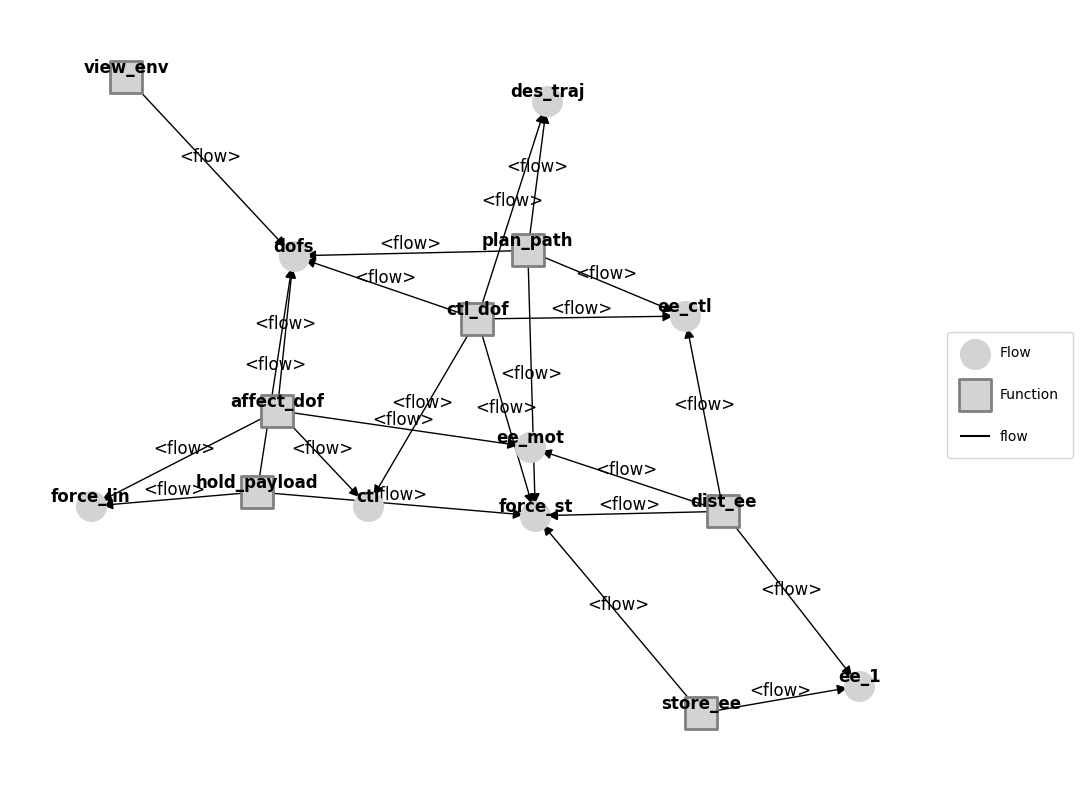

In [9]:
mg = mdl.as_modelgraph()
fig, ax = mg.draw()

This graph is often pretty ugly by default because the layout is auto-generated via an algorithm in the `networkx` package

## Making the graph pretty(er)

The outputted "Model Graph" is an object `Graph` class (which heavily uses the `networkx` library), which has built-in options for applying different styles and moving nodes.

In [10]:
# %matplotlib qt5  # use this to have the graphs open up in an external window you can interact with
# mg.move_nodes() # this lets you move the nodes around in the external window
# %matplotlib inline  # this puts the matplotlib output back in the notebook

In [ ]:
#| include: false
pos= {'drone.fxns.store_ee': [-0.85, -0.63],
        'drone.fxns.dist_ee': [-0.79, 0.09],
        'drone.fxns.affect_dof': [0.69, 0.34],
        'drone.fxns.ctl_dof': [-0.01, 0.45],
        'drone.fxns.plan_path': [-0.55, 0.8],
        'drone.fxns.hold_payload': [0.22, -0.72],
        'drone.fxns.view_env': [0.77, -0.63],
        'drone.flows.force_st': [-0.29, -0.66],
        'drone.flows.force_lin': [0.24, -0.13],
        'drone.flows.ee_1': [-0.82, -0.26],
        'drone.flows.ee_mot': [-0.1, 0.14],
        'drone.flows.ee_ctl': [-0.83, 0.45],
        'drone.flows.ctl': [0.35, 0.61],
        'drone.flows.dofs': [0.72, -0.06],
        'drone.flows.des_traj': [0.09, 0.78]}

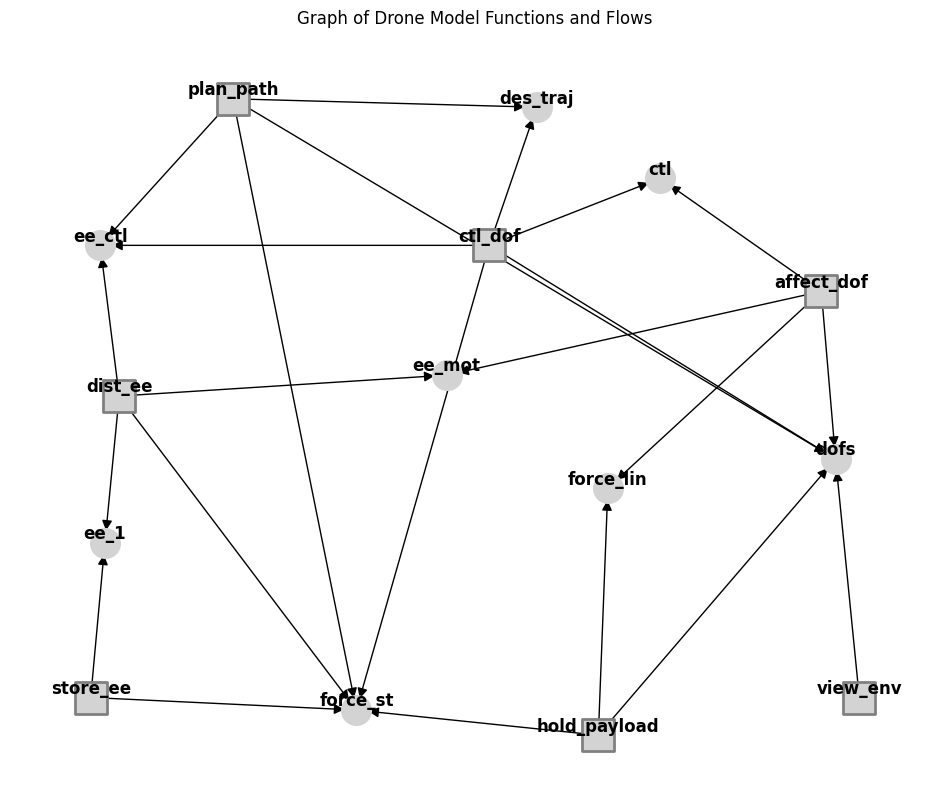

In [24]:
mg.set_pos(**pos)
mg.set_edge_labels(title="")
fig, ax = mg.draw(title="Graph of Drone Model Functions and Flows", withlegend=False)